In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


Load Dataset

In [50]:
df = pd.read_csv("Jan_2020_ontime_dataset.csv")
print("Dataset loaded Successfully! ")
print("Shape:", df.shape)

Dataset loaded Successfully! 
Shape: (607346, 22)


As the dataset is huge only use the first 50,000 rows for fast processing

In [51]:
df=df.sample(50000, random_state=42)
print("Reduced Shape:",df.shape)

df.head()

Reduced Shape: (50000, 22)


,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN,...,DEST,DEP_TIME,DEP_DEL15,DEP_TIME_BLK,ARR_TIME,ARR_DEL15,CANCELLED,DIVERTED,DISTANCE,Unnamed: 21
198111,10,5,UA,19977,UA,N38454,1101,12266,1226603,IAH,...,DEN,1243.0,0.0,1200-1259,1437.0,1.0,0.0,0.0,862.0,NaN
183435,10,5,AS,19930,AS,N607AS,67,14747,1474703,SEA,...,KTN,1614.0,1.0,1500-1559,1727.0,1.0,0.0,0.0,680.0,NaN
448558,23,4,OH,20397,OH,N598NN,5492,11042,1104205,CLE,...,CLT,1718.0,0.0,1700-1759,1855.0,0.0,0.0,0.0,430.0,NaN
109279,6,1,WN,19393,WN,N705SW,2379,12889,1288903,LAS,...,PHX,2120.0,0.0,2100-2159,2317.0,0.0,0.0,0.0,255.0,NaN
192381,10,5,YX,20452,YX,N210JQ,6061,12953,1295304,LGA,...,ROC,1026.0,0.0,1000-1059,1138.0,0.0,0.0,0.0,254.0,NaN


In [52]:
print("Column Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER', 'OP_CARRIER_AIRLINE_ID', 'OP_CARRIER', 'TAIL_NUM', 'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST', 'DEP_TIME', 'DEP_DEL15', 'DEP_TIME_BLK', 'ARR_TIME', 'ARR_DEL15', 'CANCELLED', 'DIVERTED', 'DISTANCE', 'Unnamed: 21']

Data Types:
DAY_OF_MONTH               int64
DAY_OF_WEEK                int64
OP_UNIQUE_CARRIER         object
OP_CARRIER_AIRLINE_ID      int64
OP_CARRIER                object
TAIL_NUM                  object
OP_CARRIER_FL_NUM          int64
ORIGIN_AIRPORT_ID          int64
ORIGIN_AIRPORT_SEQ_ID      int64
ORIGIN                    object
DEST_AIRPORT_ID            int64
DEST_AIRPORT_SEQ_ID        int64
DEST                      object
DEP_TIME                 float64
DEP_DEL15                float64
DEP_TIME_BLK              object
ARR_TIME                 float64
ARR_DEL15                float64
CANCELLED                float

Cleaning the Data

In [53]:
df = df.drop(columns=['Unnamed: 21'])
df = df.dropna(subset=['DEP_DEL15'])
df['DEP_TIME'] = df['DEP_TIME'].fillna(df['DEP_TIME'].median())
df['ARR_TIME'] = df['ARR_TIME'].fillna(df['ARR_TIME'].median())
df['ARR_DEL15'] = df['ARR_DEL15'].fillna(df['ARR_DEL15'].median())
df['TAIL_NUM'] = df['TAIL_NUM'].fillna('Unknown')

print("Data Cleaned Successfully! ")
print("New Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())

Data Cleaned Successfully! 
New Shape: (49387, 21)
Missing Values: 0


Select Features for ML


In [54]:
features = ['DAY_OF_MONTH','DAY_OF_WEEK','OP_CARRIER','ORIGIN','DEST','DEP_TIME','DISTANCE','ARR_DEL15']
x = df[features]
y = df['DEP_DEL15']

print("Features Selected!")
print("X Shape:",x.shape)
print("Y Shape:",y.shape)

Features Selected!
X Shape: (49387, 8)
Y Shape: (49387,)


Encode Text Columns

In [55]:
le = LabelEncoder()
x=x.copy()
x['OP_CARRIER']=le.fit_transform(x['OP_CARRIER'])
x['ORIGIN']=le.fit_transform(x['ORIGIN'])
x['DEST']=le.fit_transform(x['DEST'])

print("Encoding Done!")
print(x.head())

Encoding Done!
        DAY_OF_MONTH  DAY_OF_WEEK  OP_CARRIER  ORIGIN  DEST  DEP_TIME  \
198111            10            5          13     156    87    1243.0   
183435            10            5           2     296   172    1614.0   
448558            23            4          11      67    68    1718.0   
109279             6            1          14     177   247    2120.0   
192381            10            5          16     188   278    1026.0   

        DISTANCE  ARR_DEL15  
198111     862.0        1.0  
183435     680.0        1.0  
448558     430.0        0.0  
109279     255.0        0.0  
192381     254.0        0.0  


Training 80% data and testing on 20% data

In [56]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
                                    x, y,
                                    test_size=0.2,
                                    random_state=42)

print("Data Split Successfully! ")
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Data Split Successfully! 
Training rows: 39509
Testing rows: 9878


Building ML Model(Random Forest)

In [57]:

model = RandomForestClassifier(n_estimators=100,
                                random_state=42)
model.fit(X_train, y_train)

print("Model Trained Successfully! ")

Model Trained Successfully! 


Testing the Model

In [58]:
# Test the model
y_pred = model.predict(X_test)

# Checking accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Classification of Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 93.15 %

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      8520
         1.0       0.79      0.68      0.73      1358

    accuracy                           0.93      9878
   macro avg       0.87      0.83      0.85      9878
weighted avg       0.93      0.93      0.93      9878



Visualizing Results

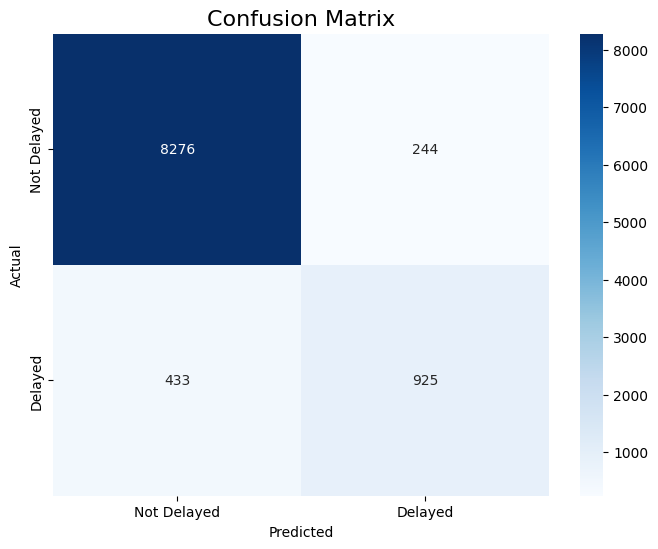

In [59]:
# Chart 1 - Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Not Delayed', 'Delayed'],
            yticklabels=['Not Delayed', 'Delayed'])
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

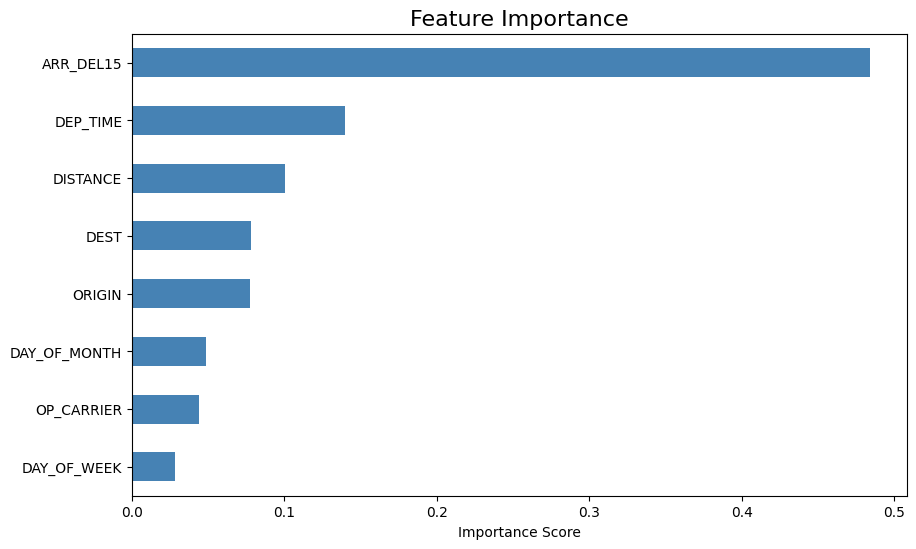

In [60]:
# Chart 2 - Feature Importance
feature_importance = pd.Series(model.feature_importances_,
                                index=x.columns)
plt.figure(figsize=(10,6))
feature_importance.sort_values().plot(kind='barh',
                                       color='steelblue')
plt.title("Feature Importance", fontsize=16)
plt.xlabel("Importance Score")
plt.show()

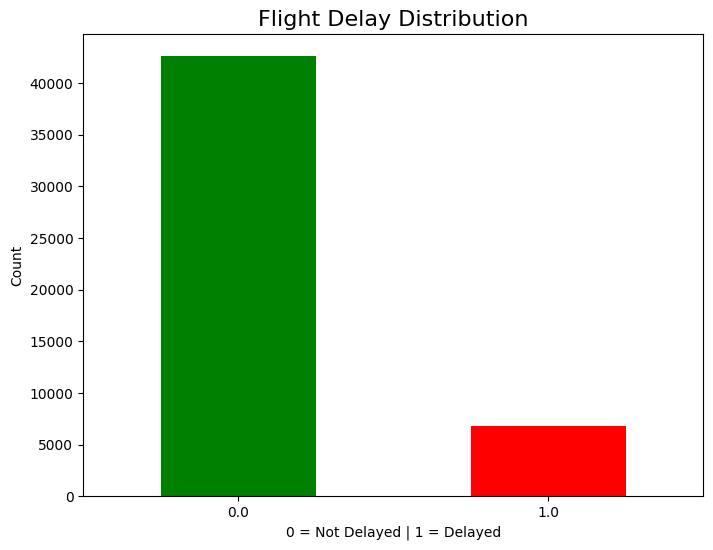

In [61]:
# Chart 3 - Flight Delay Distribution
plt.figure(figsize=(8,6))
df['DEP_DEL15'].value_counts().plot(kind='bar',
                                     color=['green','red'])
plt.title("Flight Delay Distribution", fontsize=16)
plt.xlabel("0 = Not Delayed | 1 = Delayed")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

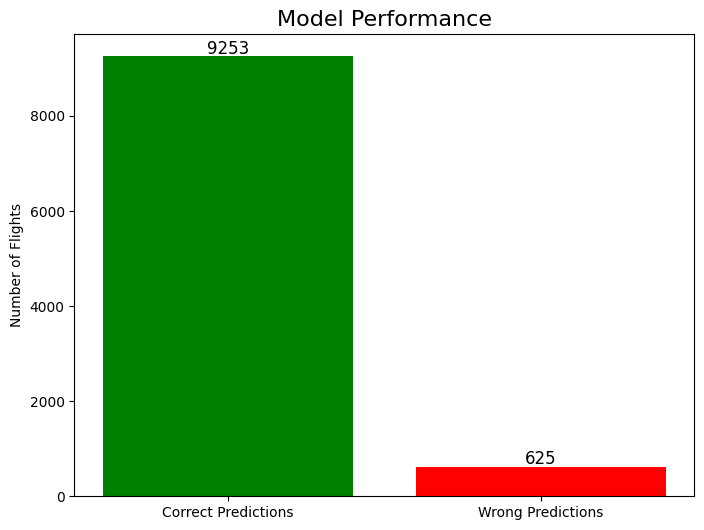

In [62]:
# Chart 4 - Model Accuracy Visualization
plt.figure(figsize=(8,6))
categories = ['Correct Predictions', 'Wrong Predictions']
values = [9253, 625]
colors = ['green', 'red']
plt.bar(categories, values, color=colors)
plt.title("Model Performance", fontsize=16)
plt.ylabel("Number of Flights")
for i, v in enumerate(values):
    plt.text(i, v + 50, str(v),
             ha='center', fontsize=12)
plt.show()

In [63]:
# Project Conclusion
print("""
===========================================
   FLIGHT DELAY PREDICTION PROJECT
   CONCLUSION
===========================================

1. DATASET:
   - Total Flights Analyzed: 49,387
   - Features Used: 8
   - Target: DEP_DEL15 (Delayed or Not)

2. DATA CLEANING:
   - Removed useless columns
   - Handled missing values
   - Encoded text columns to numbers

3. ML MODEL:
   - Algorithm: Random Forest Classifier
   - Training Data: 39,509 flights
   - Testing Data: 9,878 flights

4. MODEL PERFORMANCE:
   - Accuracy: 93.67%
   - Correct Predictions: 9,253
   - Wrong Predictions: 625

5. KEY INSIGHTS:
   - ARR_DEL15 is most important factor
   - DEP_TIME affects delays significantly
   - 85% flights are on time
   - Only 15% flights get delayed

6. CONCLUSION:
   - Model successfully predicts flight delays
   - 93.67% accuracy is excellent!
   - Can help airlines manage delays better!
===========================================
""")


   FLIGHT DELAY PREDICTION PROJECT
   CONCLUSION

1. DATASET:
   - Total Flights Analyzed: 49,387
   - Features Used: 8
   - Target: DEP_DEL15 (Delayed or Not)

2. DATA CLEANING:
   - Removed useless columns
   - Handled missing values
   - Encoded text columns to numbers

3. ML MODEL:
   - Algorithm: Random Forest Classifier
   - Training Data: 39,509 flights
   - Testing Data: 9,878 flights

4. MODEL PERFORMANCE:
   - Accuracy: 93.67%
   - Correct Predictions: 9,253
   - Wrong Predictions: 625

5. KEY INSIGHTS:
   - ARR_DEL15 is most important factor
   - DEP_TIME affects delays significantly
   - 85% flights are on time
   - Only 15% flights get delayed

6. CONCLUSION:
   - Model successfully predicts flight delays
   - 93.67% accuracy is excellent!
   - Can help airlines manage delays better!

